This is a simple notebook to generate linear data with some (non-Gaussian) scatter, and do linear fits with different loss functions.
It accompanies Chapter 5 of the book (1 of 5).  
Copyright: Viviana Acquaviva (2023)  
Modified by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [43]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model #New!
from sklearn.linear_model import HuberRegressor
import time

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

#### We begin by generating some data.

In [44]:
np.random.seed(16) #set seed for reproducibility purposes

x = np.arange(100) 

y = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) #generate some data with scatter following Poisson distribution 
                                                    #with exp value = y from linear model, centered around 0

Note that the errors here are *not* well behaved as one would need to model for parameter inference, but it doesn't matter for predictive machine learning.

Text(0, 0.5, '$y$')

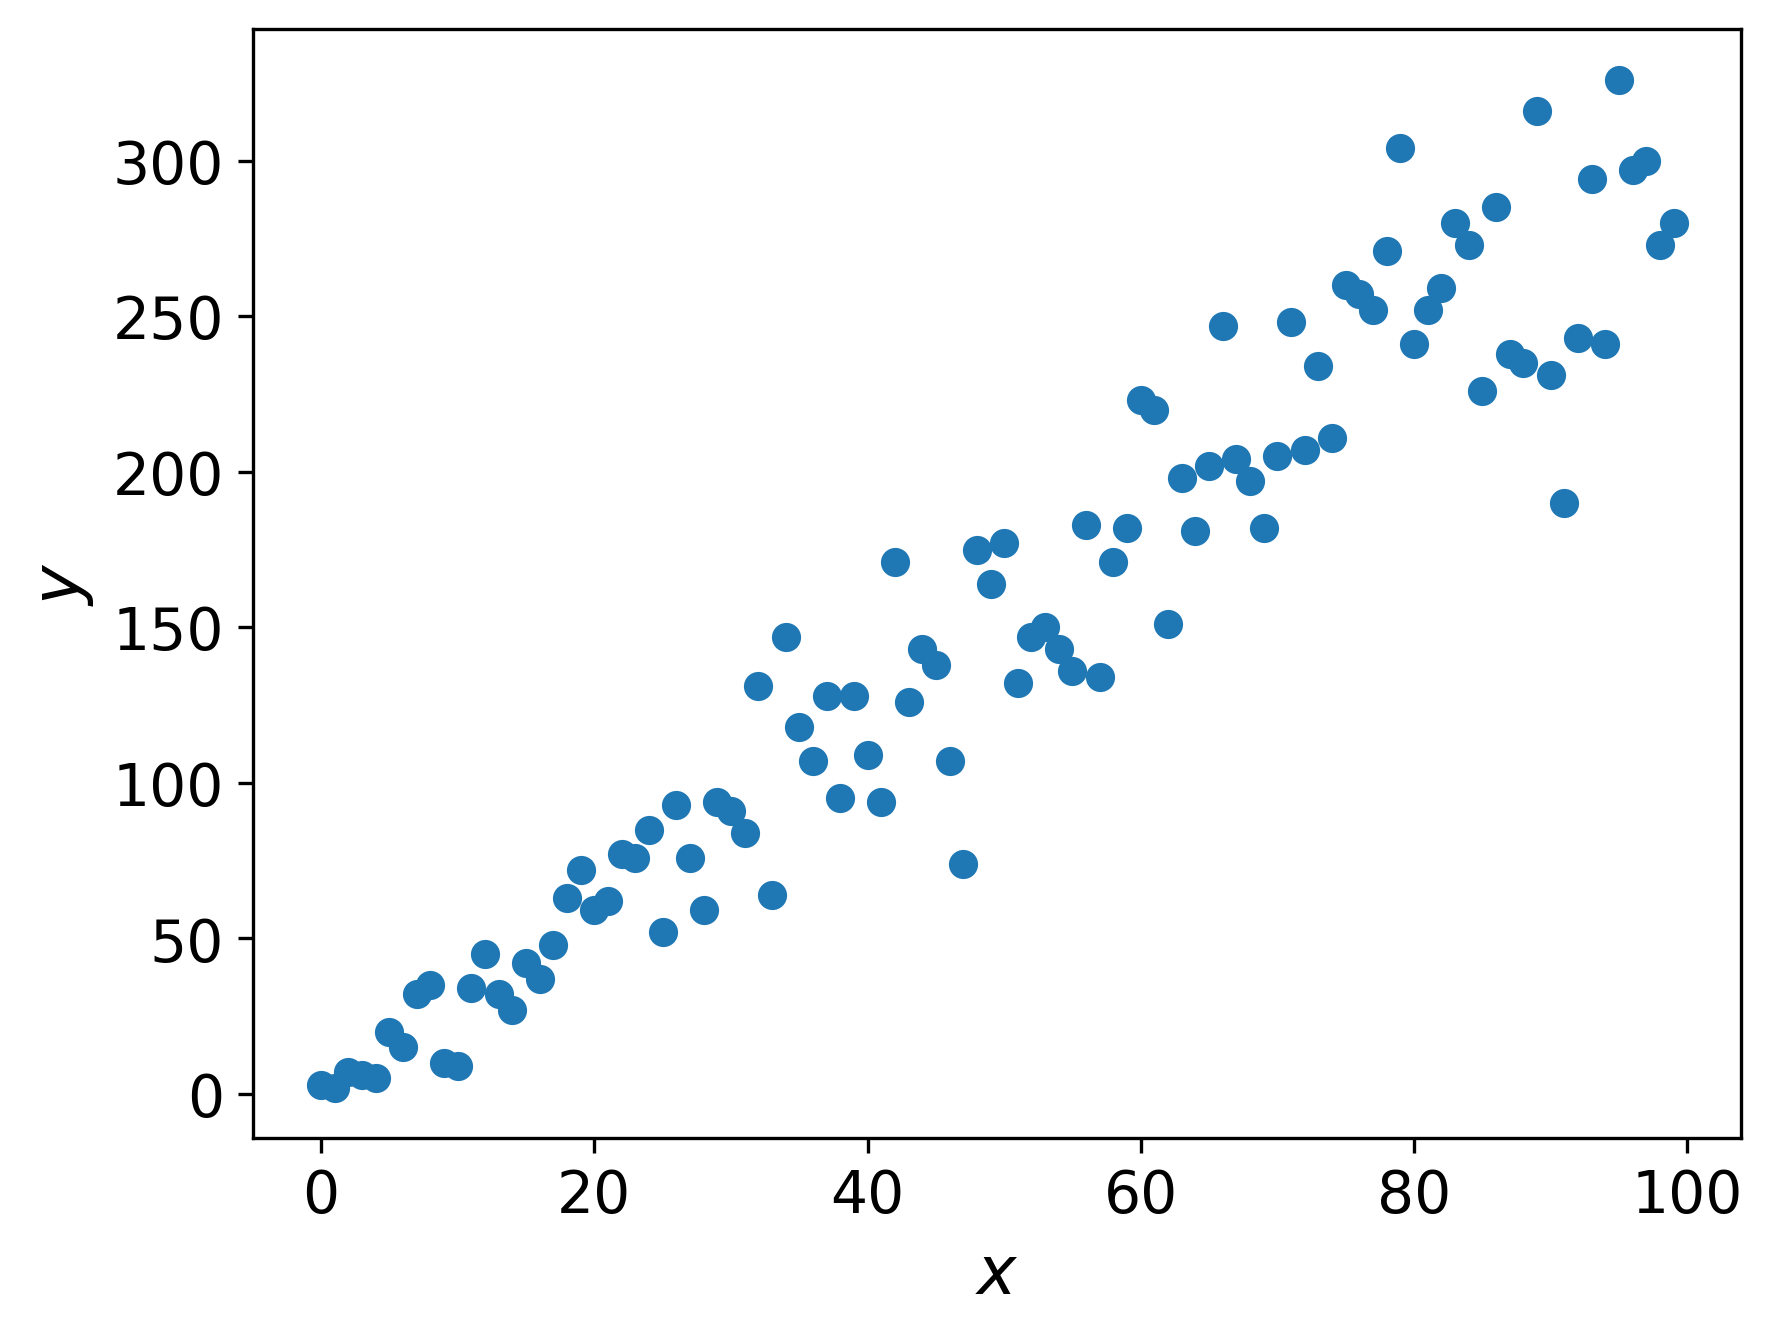

In [45]:
#Let's take a look!
fig1 = plt.figure()
plt.scatter(x, y)
plt.xlabel('$x$')
plt.ylabel('$y$')

#### Here comes the linear regression model ;) 

In [46]:
model = linear_model.LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


I can fit the model (right now, I will do it using the entire data set just to compare with the analytic solution). When only one predictor is present, I need to reshape it to column form.

In [47]:
print(x)
X = x.reshape(-1,1) # rows, columns;row = -1 used if there is a single feature
print(X[:10]) # show first 10 rows
model.fit(X,y) 

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The fitted model has attributes "coef_", "intercept_":

In [48]:
slope, intercept = model.coef_, model.intercept_
print(slope, intercept)

[3.02475848] -0.1255445544555016


Remember the "true" answer is 3, 3.

We can plot the original and the fitted line.

Text(0, 0.5, '$y$')

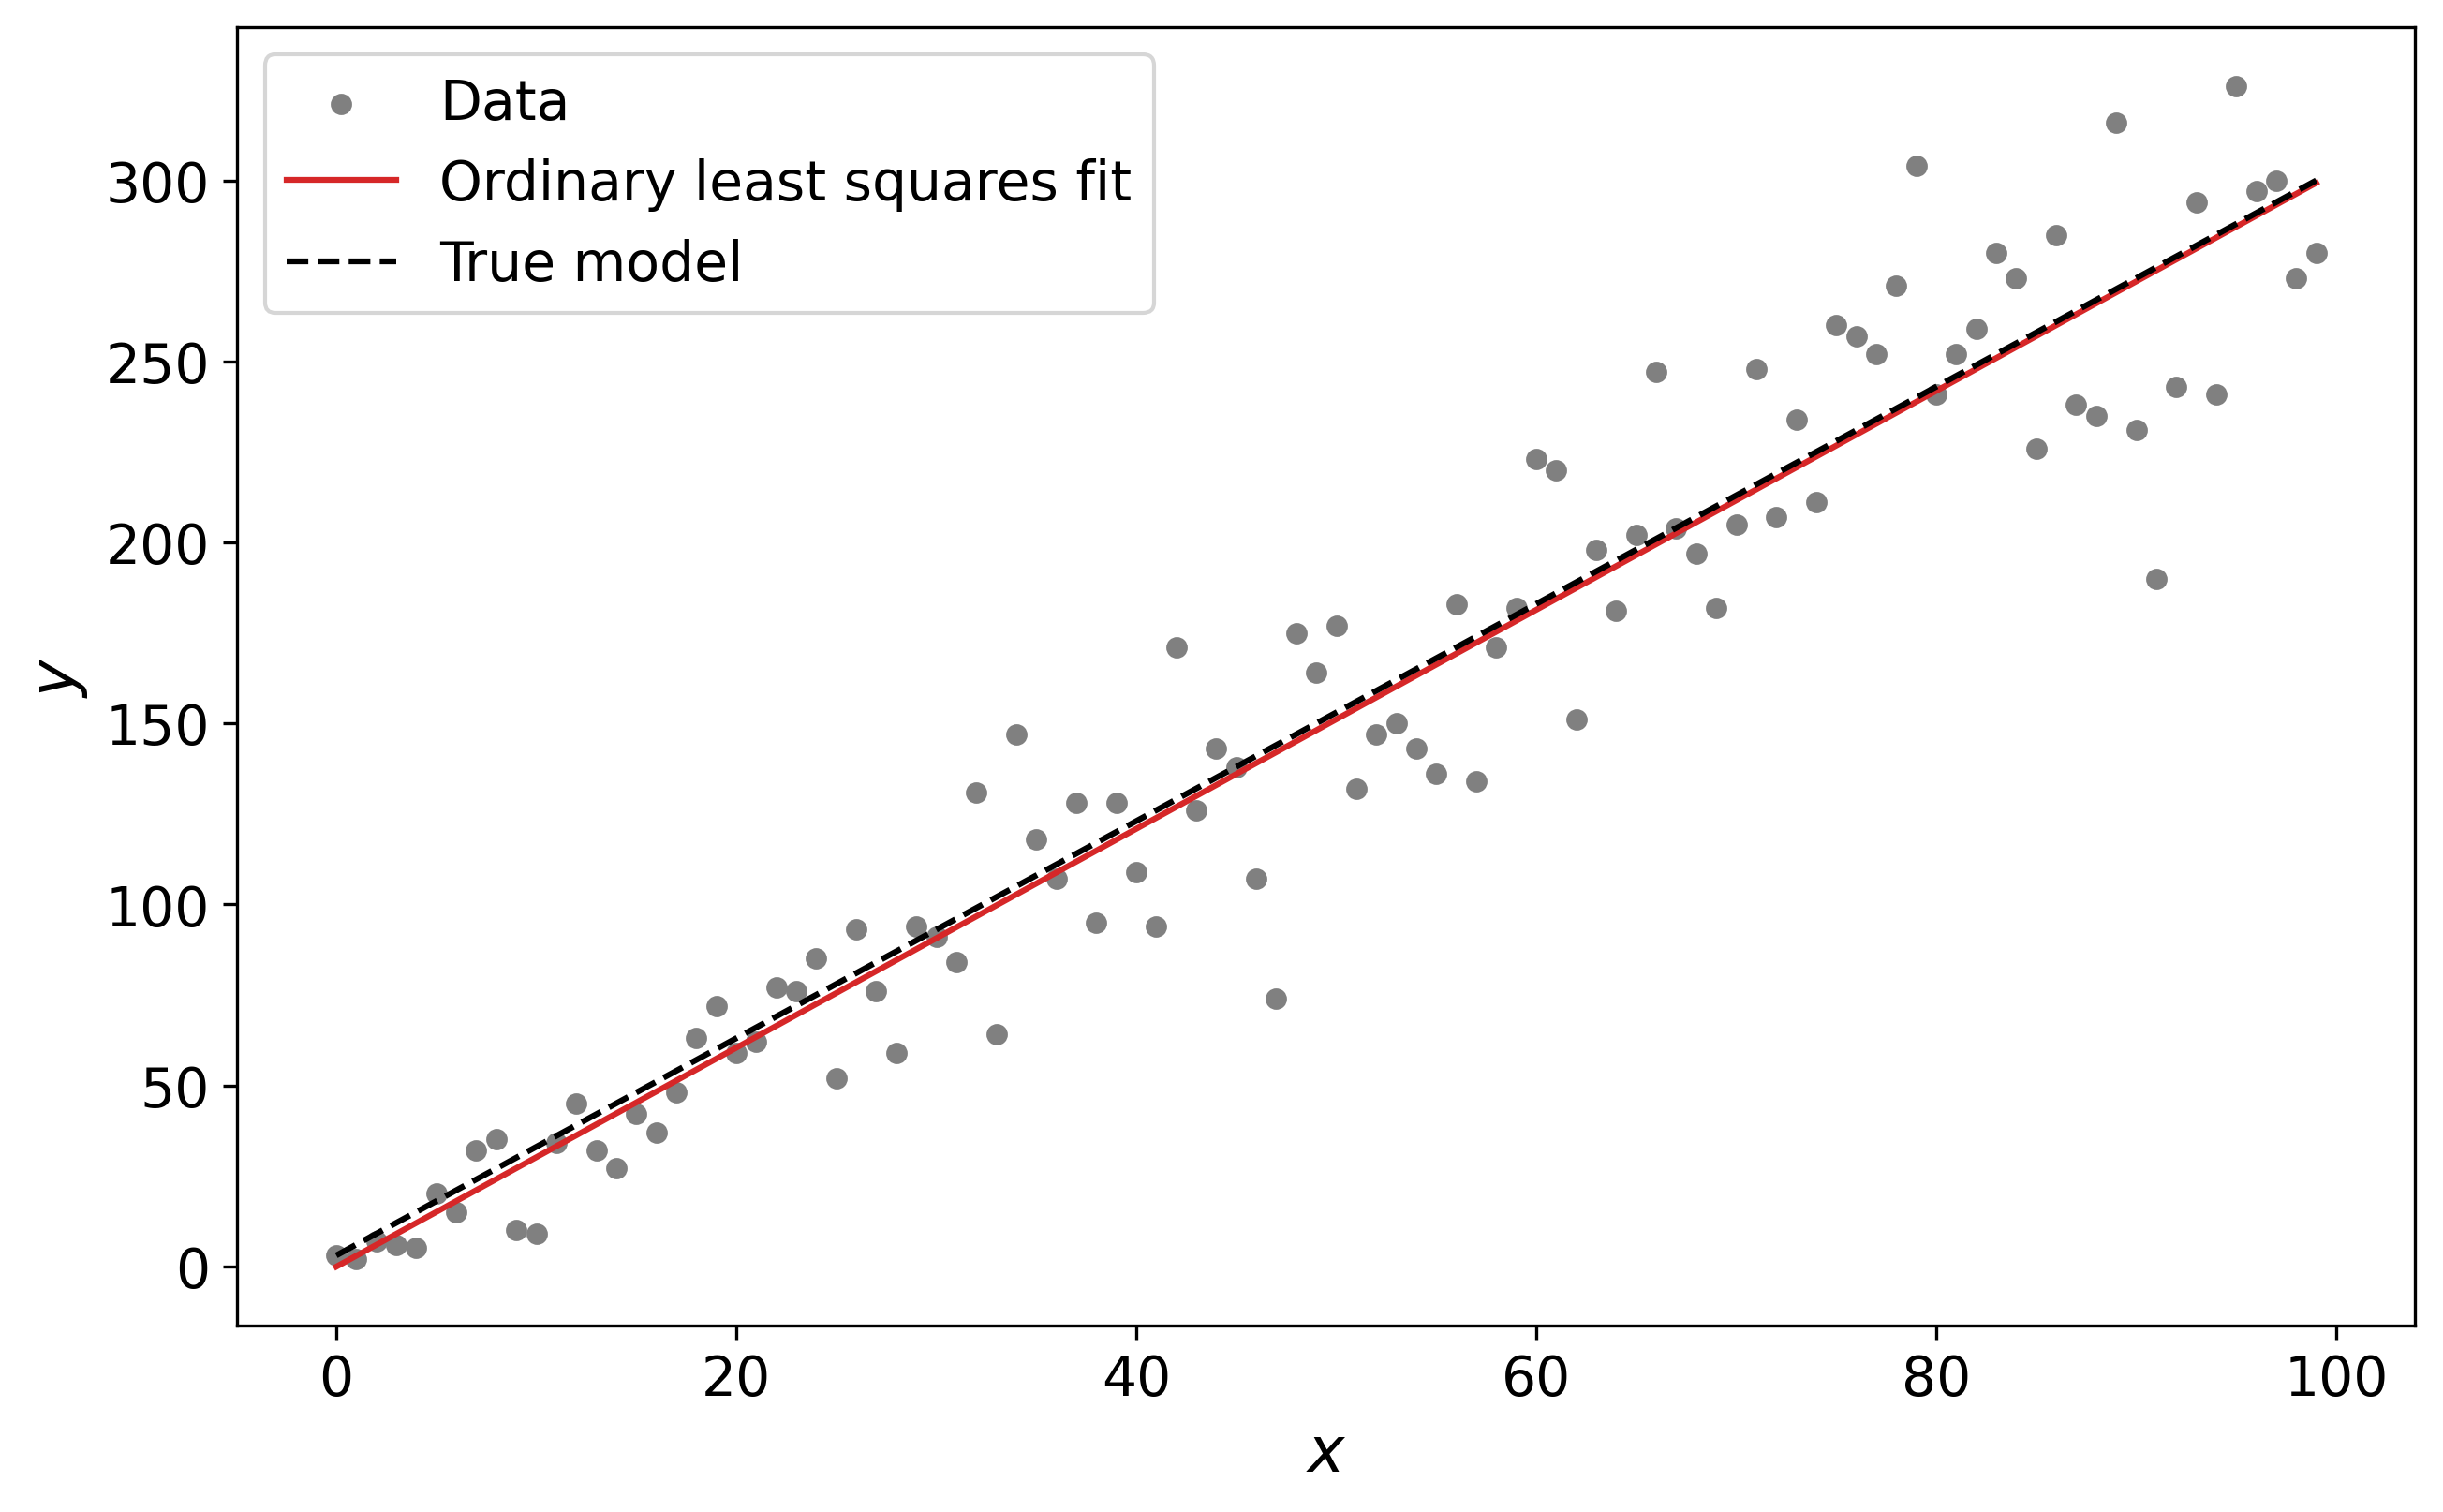

In [49]:
fig2 = plt.figure(figsize = (10,6))
plt.scatter(X,y, s = 20, c = 'gray', label = 'Data')
plt.plot(X, slope*X + intercept, c='C3', label = 'Ordinary least squares fit')
plt.plot(X, 3*X + 3, '--', c ='k', label = 'True model')
plt.legend(fontsize = 14)
plt.xlabel('$x$')
plt.ylabel('$y$')

What are the analytic predictions for the coefficients?  $(\beta_0,\beta_1)$

In [50]:
#Predictions - fill in the analytic formula

beta1 = np.sum((x - np.mean(x))*(y - np.mean(y)))/np.sum((x - np.mean(x))*(x - np.mean(x)))

beta0 = np.mean(y) - beta1*np.mean(x)

In [51]:
print('beta_0, beta_1:', beta0, beta1)

beta_0, beta_1: -0.12554455445544477 3.0247584758475847


I can also obtain the second one in the variance/covariance notation (note: a small difference is due to 1/n vs 1/(n-1) in the definition; use bias = True for consistency).

In [52]:
print('Sample Cov / Sample var:', np.cov(x,y, bias=True)[0,1]/np.var(x))

Sample Cov / Sample var: 3.0247584758475843


#### We can (and should!) do cross validation and all the nice things we have learned to do for classification problems.

In [53]:
cv = KFold(n_splits = 5 , shuffle = True , random_state = 10)

In [54]:
scores = cross_validate(model, X, y, cv = cv, return_train_score = True)
scores

{'fit_time': array([0.00099707, 0.        , 0.00099802, 0.        , 0.        ]),
 'score_time': array([0.        , 0.00101328, 0.        , 0.00099921, 0.        ]),
 'test_score': array([0.9165209 , 0.89174158, 0.94218009, 0.84836725, 0.94721595]),
 'train_score': array([0.92686135, 0.92950195, 0.91582181, 0.93664738, 0.91668227])}

In [55]:
print('Test R^2 scores:', '{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train R^2 scores:', '{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test R^2 scores: 0.909 0.036
Train R^2 scores: 0.925 0.008


### Questions: 

- What are the scores that are being printed out?

- How are the scores? 

- Does it suffer from high variance? High bias?

- What would happen to the scores if we increased the scatter (noise)?

### <font color='green'> Scoring in regression problems. </font>

### Here is a way to visualize all the available scorers.

In [56]:
#print(sorted(sklearn.metrics.SCORERS.keys())) # does not work
print(sorted(sklearn.metrics.get_scorer_names()))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

### Do you recognize some of them?

Let's see if we can find the MSE.

In [57]:
scores = cross_validate(model, X, y, cv = cv, scoring = 'neg_mean_squared_error', return_train_score = True, return_estimator = True)
slopes, intercepts = [], []
for mod in scores['estimator']:
    slopes.append(mod.coef_)
    intercepts.append(mod.intercept_)
print('slope = %.3f +/- %.3f, intercept = %.3f +/- %.3f' % (np.mean(slopes),np.std(slopes),np.mean(intercepts),np.std(intercepts)))
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

slope = 3.025 +/- 0.060, intercept = -0.104 +/- 2.571
Test scores: -668.738 174.422
Train scores: -612.142 38.181


Something to note is that estimators of performance of the "error" type (in other words, the lower, the better) receive a negative sign in sklearn. This is just to maintain consistency with the "higher score = better" framework.

Can also try the Mean Absolute Error:

In [58]:
scores = cross_validate(model, X, y, cv = cv, scoring = 'neg_mean_absolute_error', return_train_score = True)
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test scores: -19.461 1.948
Train scores: -18.925 0.580


Finally, by plotting the residuals, we can see that they are not independent of x (the assumptions of the probabilistic linear model are not satisfied). But that doesn't mean we can't create a model.

Text(0, 0.5, 'residuals $(\\hat{y}-y)$')

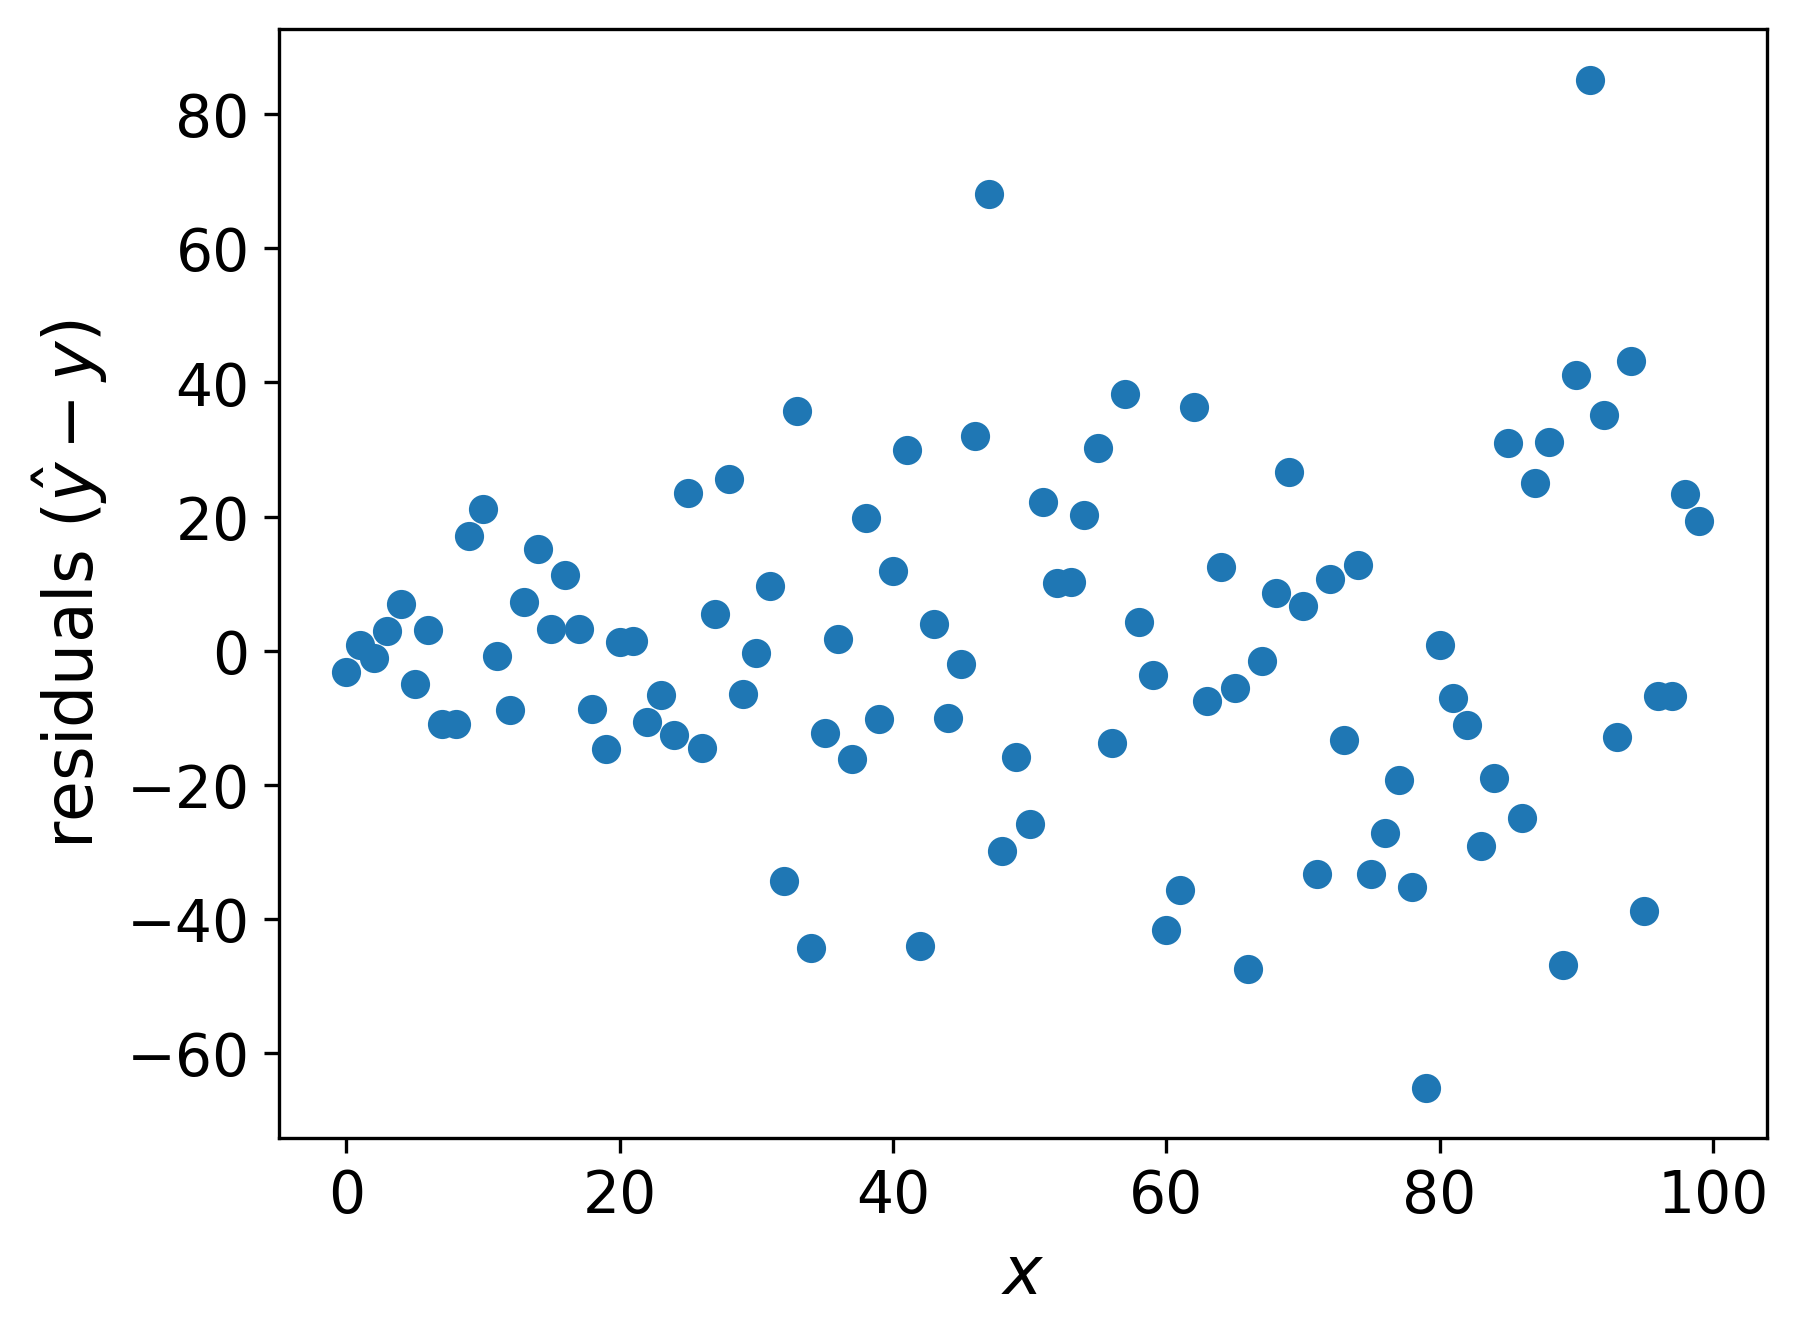

In [59]:
fig3 = plt.figure()
#plt.scatter(x, slope*x + intercept - y, color = 'b', label = 'Residuals')
plt.scatter(x, slope*x + intercept - y)
plt.xlabel('$x$')
plt.ylabel('residuals $(\\hat{y}-y)$')
#plt.legend();

### Custom scores

We might like to implement a scorer where we care about percentage error instead. Here is how to do a custom scorer:

In [60]:
from sklearn.metrics import make_scorer

In [61]:
def mape(true,pred): #Modified Mean Absolute Percentage Error
    return np.mean(np.abs(true-pred)/(0.5*(true+pred)))

mape_scorer = make_scorer(mape, greater_is_better = False)

In [62]:
scores = cross_validate(model, X, y, cv = cv, scoring = mape_scorer, return_train_score = True)
scores

{'fit_time': array([0.00099921, 0.00099826, 0.        , 0.00099969, 0.        ]),
 'score_time': array([0.00100279, 0.        , 0.00100112, 0.        , 0.        ]),
 'test_score': array([-0.20708215, -0.16840171, -0.1728769 , -0.15332491, -0.20178944]),
 'train_score': array([-0.1789928 ,  0.38976175, -0.19881487, -0.40769513, -0.18684556])}

In [63]:
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

Test scores: -0.181 0.021
Train scores: -0.117 0.267


#### Note: as we already discussed, so far we have not changed the loss function (MSE), or the coefficients of the model. We have only looked at different evaluation metrics.

#### <font color = 'green'> Question 1: would the best fit line change if we optimize a different loss function? </font>

Yes!

#### <font color = 'green'> Question 2: How can we implement that without an analytic solution? </font>

For example, with a Grid Search.


This is an example using the Mean Square Error.

In [64]:
beta0 = np.linspace(-5,5,200)
beta1 = np.linspace(2.7,3.3,200)

In [65]:
mse = np.empty((200,200))

N = len(y)
for i,b0 in enumerate(beta0):
    for j,b1 in enumerate(beta1):
        mse[i,j] = np.sum((b0 + b1*x - y)**2)/N

Text(0, 0.5, '$\\beta_1$')

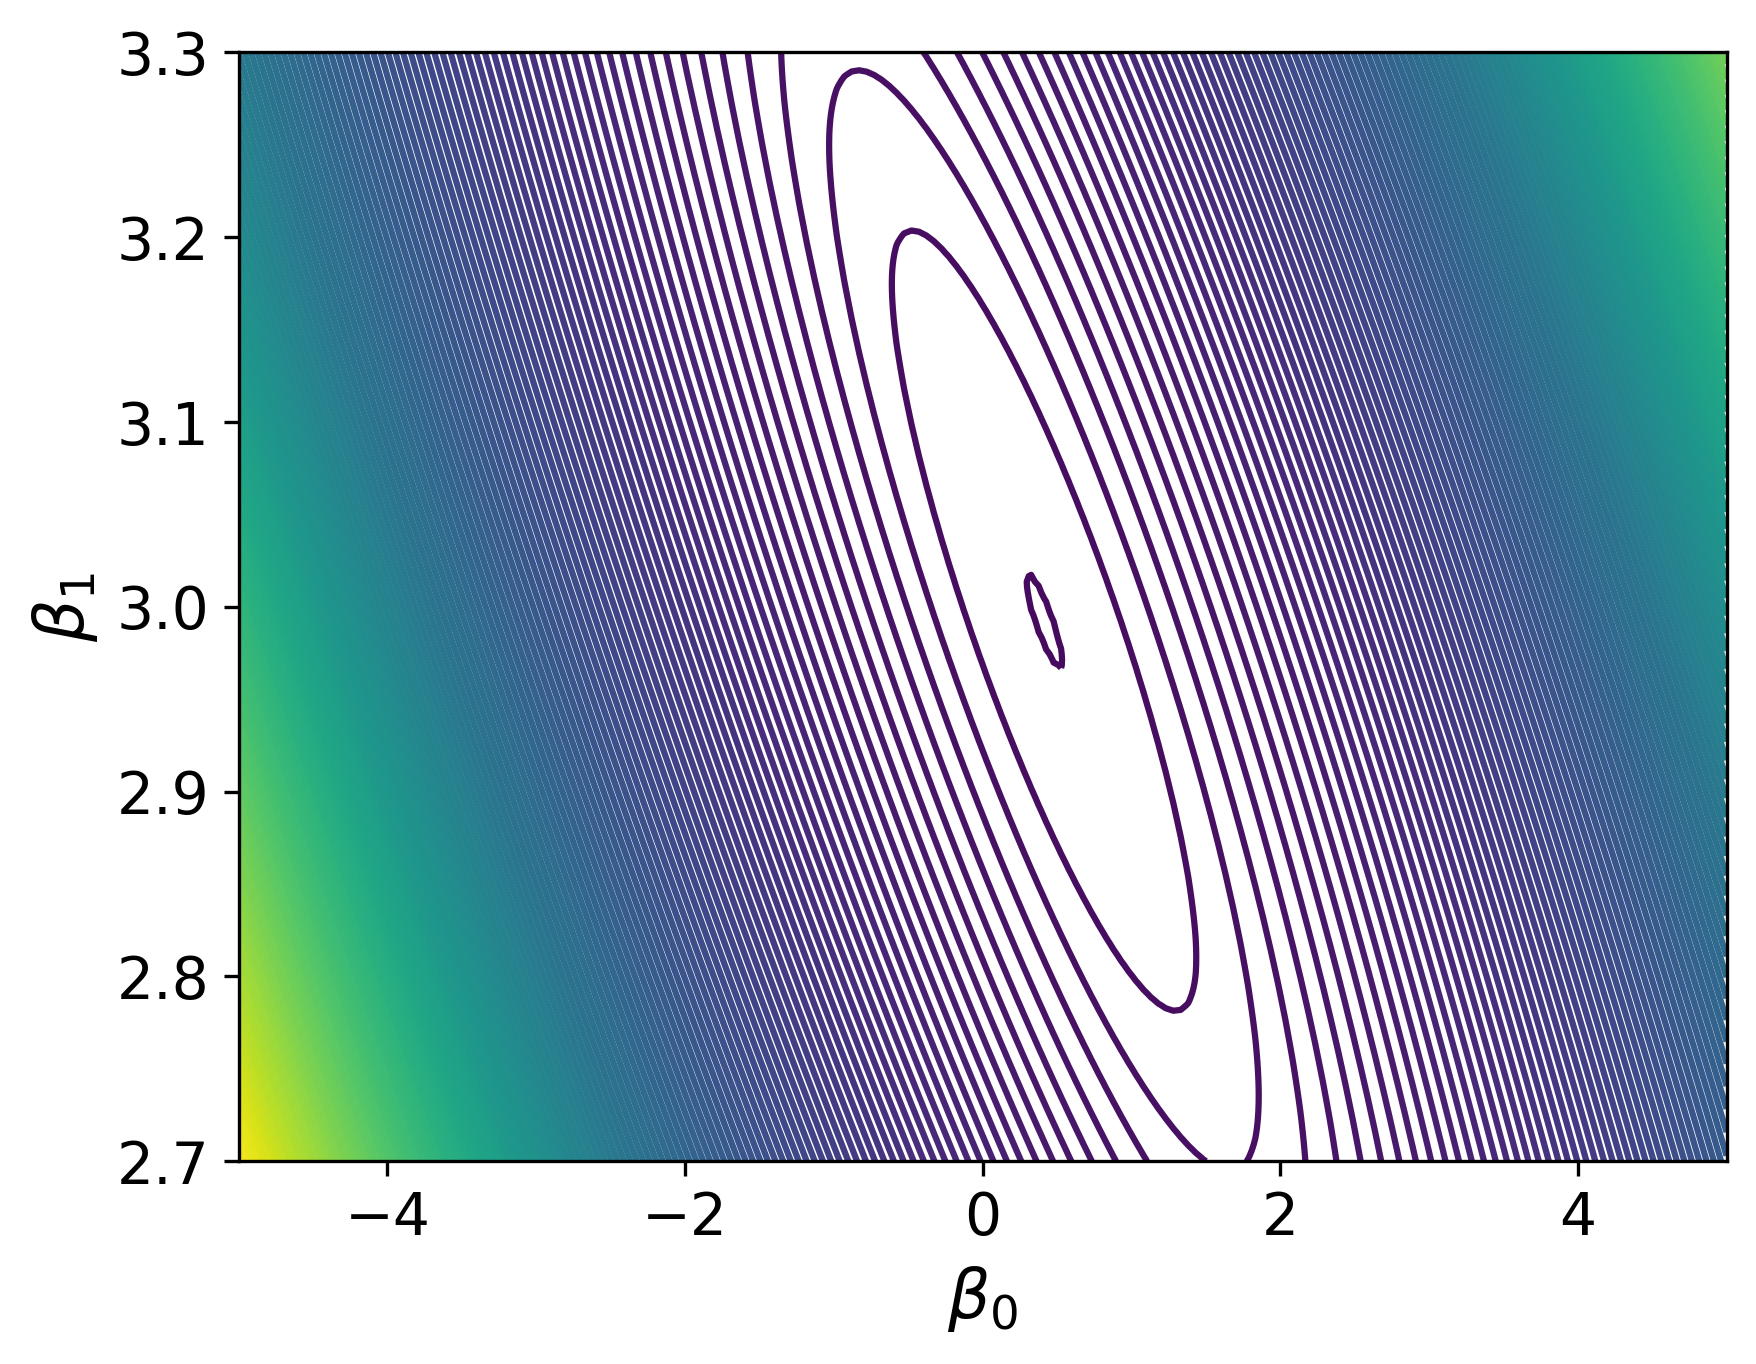

In [66]:
fig4, ax = plt.subplots()
levels = np.logspace(2.78,3.06,130)
CS = ax.contour(beta0, beta1, mse, levels)
#print(CS.levels)
plt.xlabel('$\\beta_0$')
plt.ylabel('$\\beta_1$')

Text(0.5, 0, 'MSE')

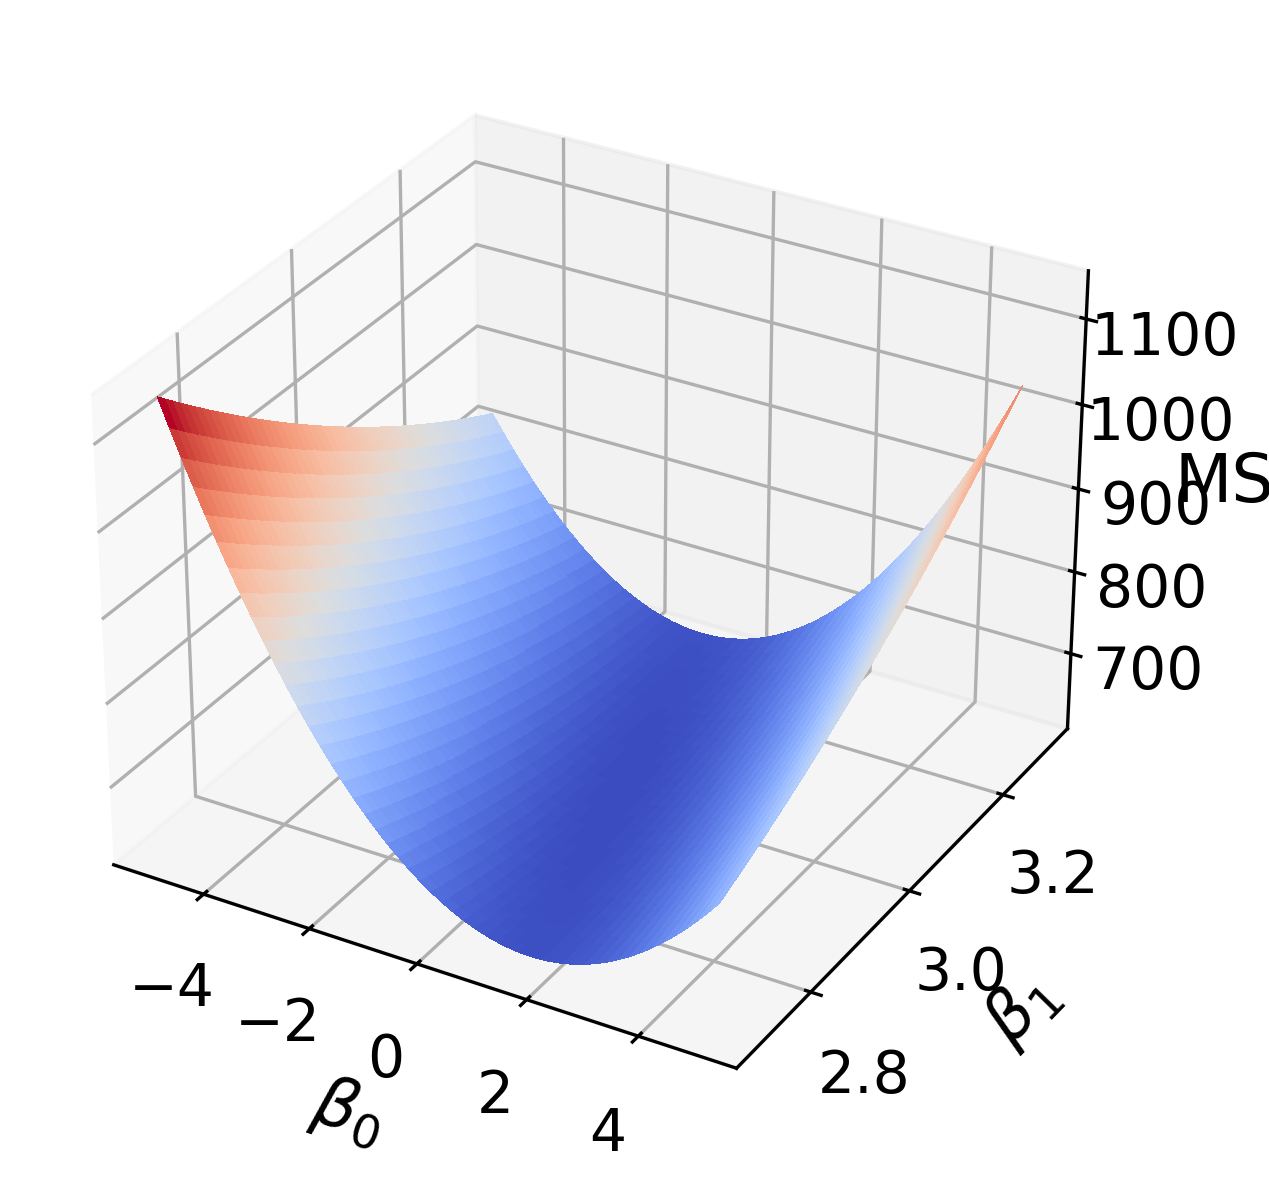

In [67]:
fig5, ax = plt.subplots(subplot_kw={"projection": "3d"})
b0, b1 = np.meshgrid(beta0,beta1)
surf = ax.plot_surface(b0, b1, mse, cmap=matplotlib.cm.coolwarm, linewidth=0, antialiased=False)
plt.xlabel('$\\beta_0$')
plt.ylabel('$\\beta_1$')
ax.set_zlabel('MSE')

To get the indices of the 2D array, I need to unravel it

In [68]:
besti, bestj = np.unravel_index(mse.argmin(), mse.shape)
print(besti, bestj)

96 108


I can now find the minimum MSE (not very informative, TBH) and the best fit coefficients:

In [69]:
mse[besti,bestj]

np.float64(617.7599159364663)

In [70]:
beta0[besti], beta1[bestj]

(np.float64(-0.17587939698492416), np.float64(3.0256281407035175))

Question: How do they compare to the ones found by the Linear Model / analytic ones? .... 

It will be interesting to see what happens to the parameters if we use a different loss function (MAE, MAPE, Huber loss).

However, because these data are so regular, it's kind of boring, so before trying the different losses let's inject some outliers in the data.

### What happens when we add outliers?

In [71]:
np.random.seed(12) #set 
out = np.random.choice(100,15) #select 15 outlier indices
y_wo = np.copy(y)
np.random.seed(12) #set again
y_wo[out] = y_wo[out] + 5*np.random.rand(15)*y[out]

Text(0, 0.5, '$y$')

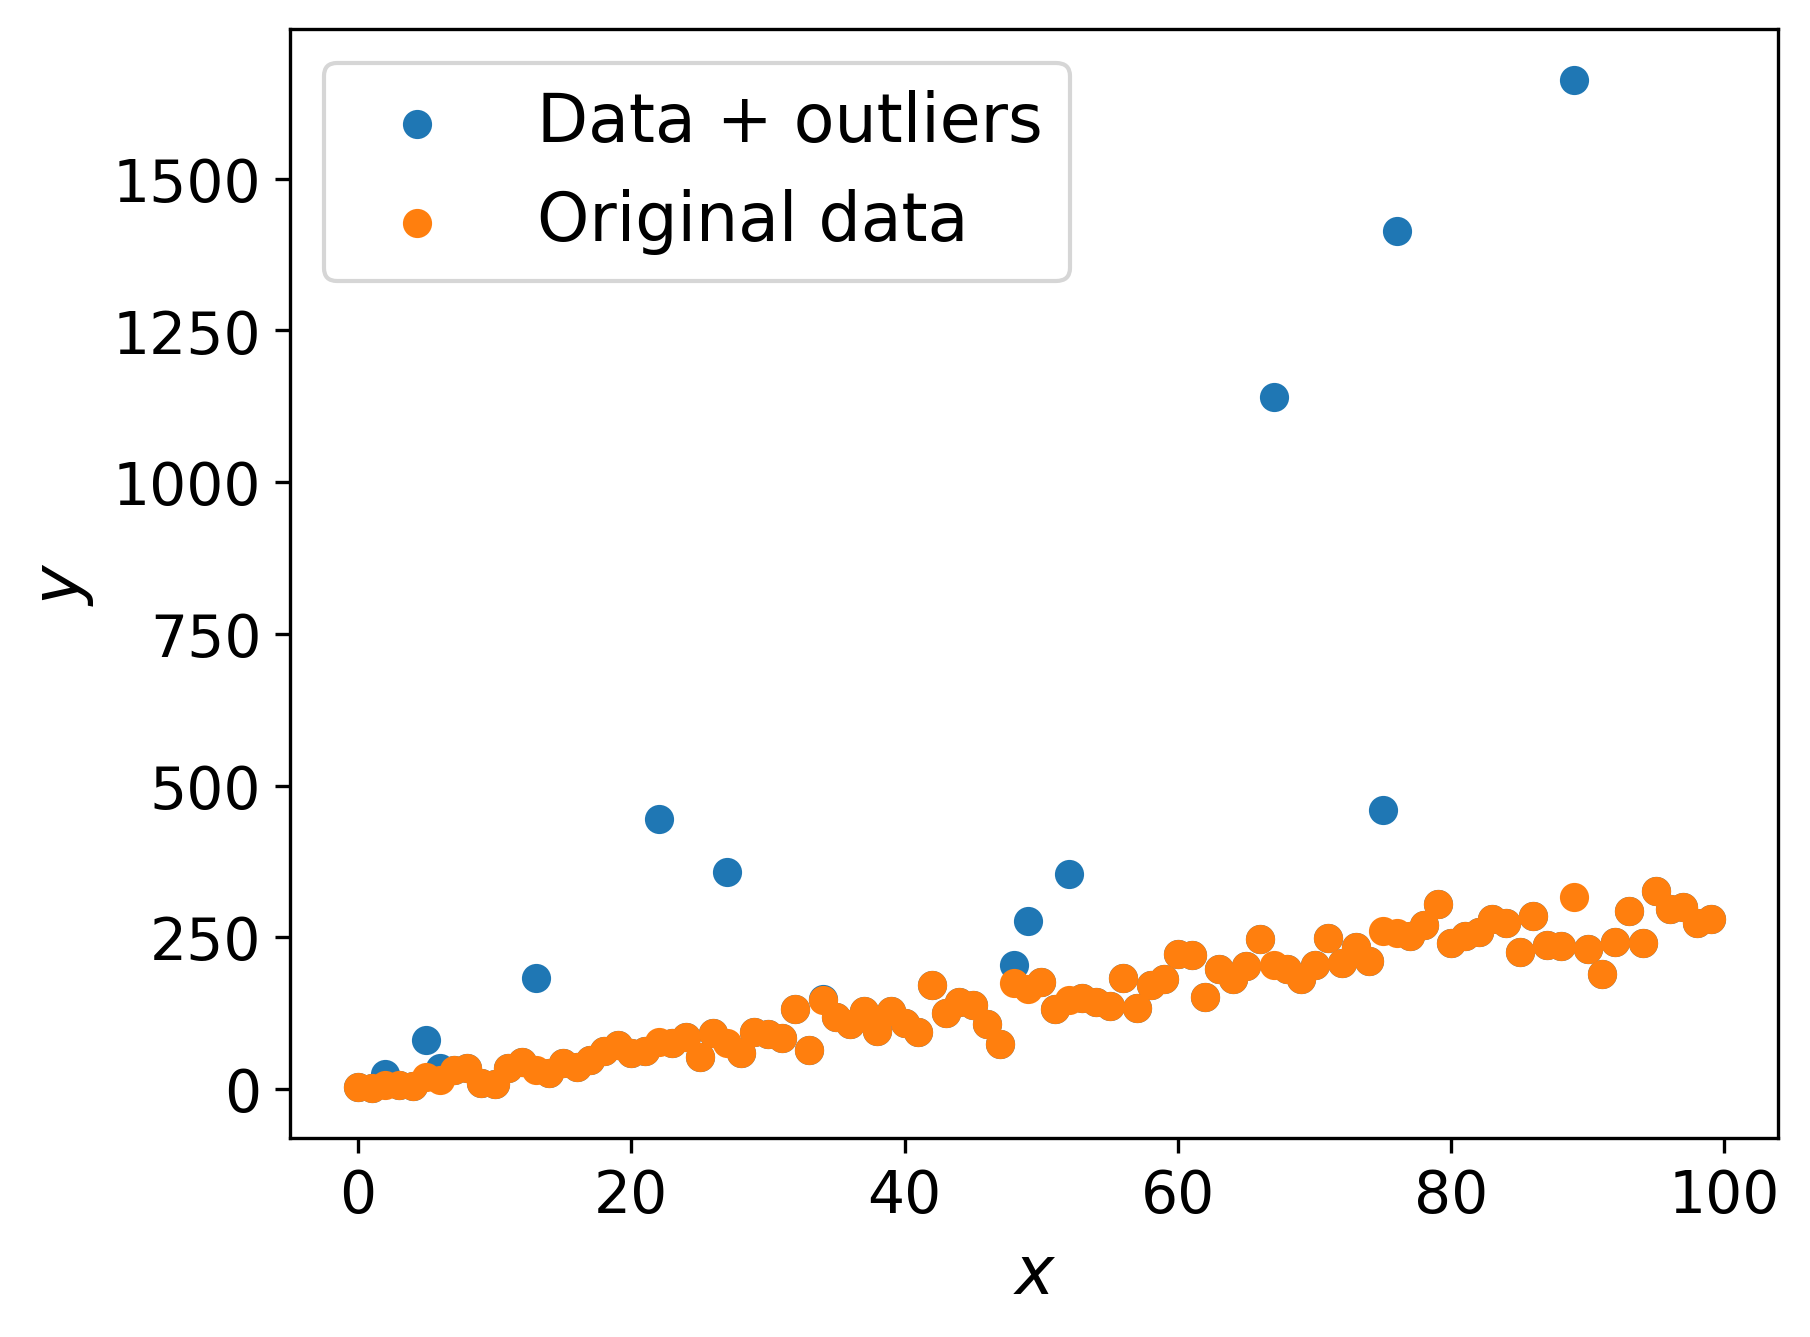

In [72]:
fig5 = plt.figure()
plt.scatter(x,y_wo, label = 'Data + outliers')
plt.scatter(x,y, label = 'Original data')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')

We can see the effect for the MSE loss right away:

In [73]:
model.fit(X,y_wo)
y_pred = model.predict(X)
MSE = metrics.mean_squared_error(y_wo, y_pred)
slope, intercept, score = model.coef_, model.intercept_, model.score(X,y_wo) # the only option for score here is R^2
print(slope, intercept, MSE, score)

[3.97842184] 1.5481188118811815 43259.081624722465 0.23364219310419954


In [74]:
scores = cross_validate(model, X, y_wo, cv = cv, scoring = 'neg_mean_squared_error', return_estimator = True, return_train_score = True)
slopes, intercepts = [], []
for mod in scores['estimator']:
    slopes.append(mod.coef_)
    intercepts.append(mod.intercept_)
#print(slopes)
#print(intercepts)
print('slope = %.3f +/- %.3f, intercept = %.3f +/- %.3f' % (np.mean(slopes),np.std(slopes),np.mean(intercepts),np.std(intercepts)))
print('Test scores:','{:.3f}'.format(scores['test_score'].mean()), '{:.3f}'.format(scores['test_score'].std()))
print('Train scores:','{:.3f}'.format(scores['train_score'].mean()), '{:.3f}'.format(scores['train_score'].std()))

slope = 3.991 +/- 0.457, intercept = 1.403 +/- 18.610
Test scores: -45271.504 31660.135
Train scores: -43034.304 7830.667


Text(0, 0.5, '$y$')

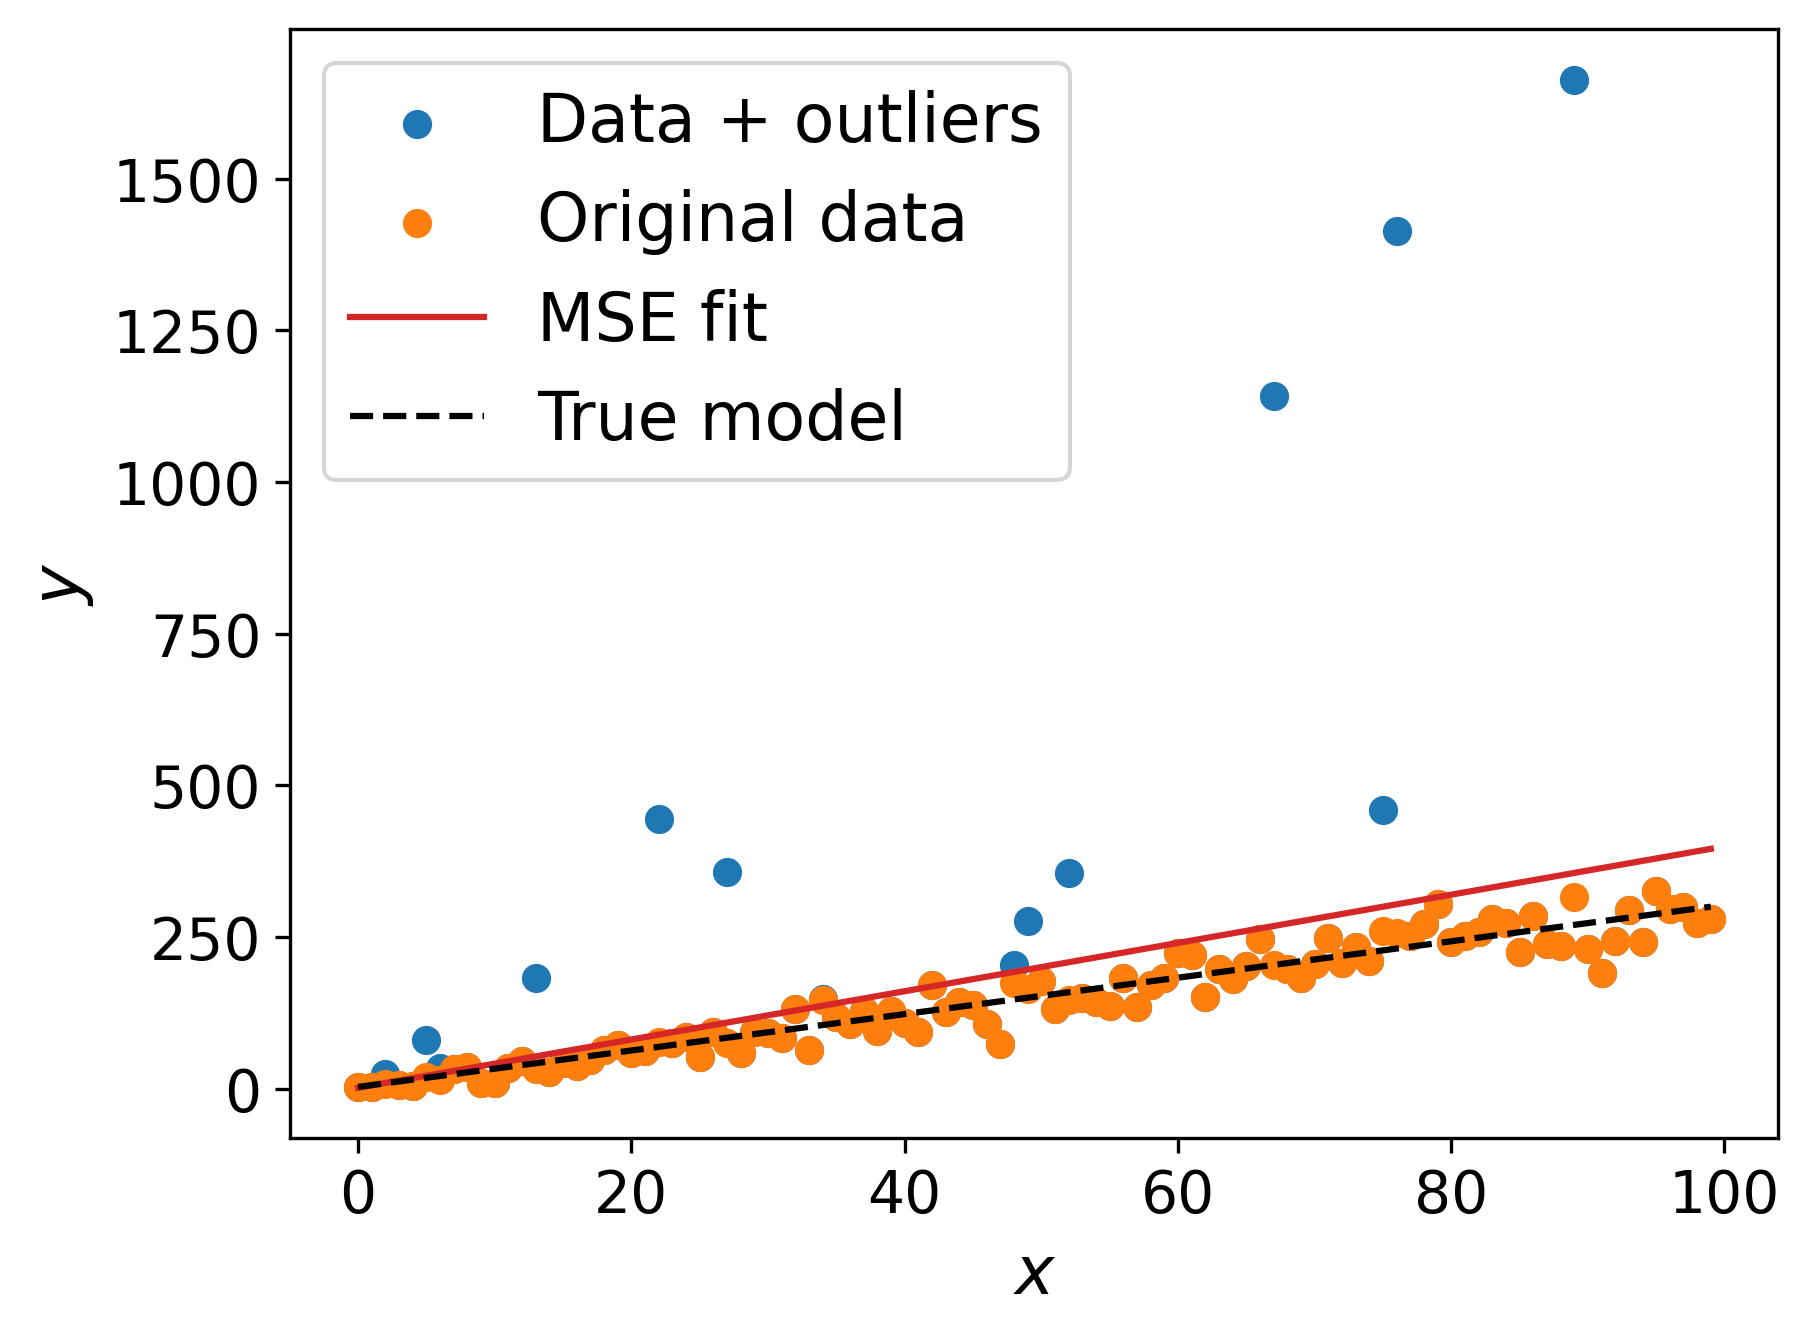

In [75]:
fig6 = plt.figure()
plt.scatter(x,y_wo, label = 'Data + outliers')
plt.scatter(x,y, label = 'Original data')
plt.plot(X, slope*X + intercept, c='C3', label = 'MSE fit')
plt.plot(X, 3*X + 3, '--', c ='k', label = 'True model')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')

# Assignment 6:

1. Start with the code LinReg.ipynb Download LinReg.ipynbfrom class.  Define your own Huber loss function in python, following this formula:

$L=\frac{1}{2}(\hat y−y)^2$  for $|\hat y−y|≤δ$

$L=δ(|y^2−y|−\frac{δ}{2})$
   otherwise

2. Create a Huber scoring function and find the train/test scores from the MSE fit to the dataset with outliers (see example in code for MAPE).  For δ, you can try the standard deviation of the y values.
3. Use a grid-search to fit the dataset with outliers while using the Huber loss function.  (Note the built-in function GridSearchCV cannot do this.  You have to do it manually:  loop over slope and intercept, predict the y values, and calculate the score.)  Report the fit parameters and Huber score, and plot the fit.  Compare to the results from scikitlearn's HuberRegressor.
4. Referencing LinReg_Grad.ipynb Download LinReg_Grad.ipynb, implement a gradient method for the Huber loss function and compare the results with part (3).

In [98]:
def hubby(true,pred,b0,b1):
    pred = b0 + b1*pred
    delta = np.std(pred)
    MSE_function = 1/2*np.mean((true-pred)**2)
    if np.mean(np.abs(true-pred)) <= delta:
        return MSE_function
    else:
        return delta*(np.abs(true**2-pred)-1/2*delta)

hubby_scorer = make_scorer(hubby, greater_is_better = False)

MAPE Scores:

Test scores: -45271.504 31660.135
Train scores: -43034.304 7830.667

In [104]:
model_huber = hubby(y,y_pred,1,100)

model_huber

array([-8.96077507e+07, -8.24633984e+07, -7.45973943e+07, -6.75685062e+07,
       -6.05107521e+07, -4.78818464e+07, -4.31911101e+07, -2.44425976e+07,
       -1.43250400e+07, -2.33456869e+07, -1.64033971e+07,  6.32863311e+06,
        2.60874581e+07,  1.88565075e+07,  2.18152797e+07,  4.39699884e+07,
        4.54854571e+07,  6.61968624e+07,  9.74443832e+07,  1.22197038e+08,
        1.04834097e+08,  1.17289806e+08,  1.54599202e+08,  1.59607465e+08,
        1.87737450e+08,  1.29702216e+08,  2.22723127e+08,  1.88473535e+08,
        1.62566237e+08,  2.47071657e+08,  2.46277840e+08,  2.35813890e+08,
        3.88876226e+08,  2.07525141e+08,  4.67507401e+08,  3.63806045e+08,
        3.35300800e+08,  4.13744346e+08,  3.14748159e+08,  4.28177381e+08,
        3.70401942e+08,  3.33669867e+08,  6.35392465e+08,  4.49711469e+08,
        5.22930256e+08,  5.09868359e+08,  4.07465976e+08,  3.28473975e+08,
        6.98666890e+08,  6.52062620e+08,  7.23260782e+08,  5.29785947e+08,
        5.97404716e+08,  

In [ ]:
# Define search range based on data
# You may need to adjust these ranges based on your data
slope_range = np.linspace(-5, 10, 100)  # 50 points between -5 and 10
intercept_range = np.linspace(-10, 10, 100)  # 50 points between -10 and 10

best_score = 0
best_params = {'slope': None, 'intercept': None}
results = []

# Grid search
for slope in slope_range:
    for intercept in intercept_range:
        # Make predictions
        y_pred = slope * X.ravel() + intercept
        
        # Calculate Huber loss
        score = hubby(y, y_pred)
        results.append({
            'slope': slope,
            'intercept': intercept,
            'loss': score
        })
        
        # Update best parameters
        if score < best_score:
            best_score = score
            best_params['slope'] = slope
            best_params['intercept'] = intercept

print(f"Best parameters from manual grid search:")
print('final result for intercept, slope = ', f"[{best_params['intercept']:.4f}]", f"[{best_params['slope']:.4f}]")
print(f"  Huber Loss: {best_score:.4f}")

# Fit sklearn's HuberRegressor for comparison
huber = HuberRegressor(epsilon=1.35, max_iter=10000)  # epsilon=1.35 is default delta
huber.fit(X, y)

print(f"\nScikit-learn HuberRegressor results:")
print('final result for intercept, slope = ', f"[{huber.intercept_:.4f}]", f"[{huber.coef_[0]:.4f}]")
print(f"  Huber Loss: {hubby(y, huber.predict(X)):.4f}")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
X = np.c_[np.ones((100, 1)), x]  

### Batch Gradient Descent (BGD)

In [ ]:
start_time = time.perf_counter()

np.random.seed(10) #same initial conditions for all
beta = np.random.randn(2,1)
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.0001
n_iterations = 1000 #try changing this number!
N = len(x)
beta_path_bgd = []

for iteration in range(n_iterations):
    gradients = 2/N * X.T.dot(X.dot(beta) - y_wo.reshape(-1,1))
    beta = beta - eta * gradients
    beta_path_bgd.append(beta)

beta_path_bgd = np.array(beta_path_bgd) #save the path

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_bgd = beta #final result
print('final result for intercept, slope = ', beta_bgd[0], beta_bgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.005588699947111309
final result for intercept, slope =  [1.38909891] [3.98081931]


In [ ]:
loss_bgd = hubby(y_wo.reshape(-1,1), X.dot(beta_bgd))
loss_bgd

np.float64(21629.544020929476)

### Stochastic Gradient Descent (SGD)

In [ ]:
start_time = time.perf_counter()

np.random.seed(10) #same initial conditions for all
beta = np.random.randn(2,1) 
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.000005 # lower learning rate
n_iterations = 10000 # more iterations are needed to get in the right ballpark!
beta_path_sgd = []

for epoch in range(n_iterations):
        random_index = np.random.randint(N) # pick one example from the data 
        x_one = X[random_index:random_index+1]
        y_one = y_wo[random_index:random_index+1]
        gradients = 2 * x_one.T.dot(x_one.dot(beta) - y_one)
        beta = beta - eta * gradients
        beta_path_sgd.append(beta)                 

beta_path_sgd = np.array(beta_path_sgd)

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_sgd = beta
print('final result for intercept, slope = ', beta_sgd[0], beta_sgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.05978120001964271
final result for intercept, slope =  [1.3552955] [4.17721319]


In [ ]:
loss_sgd = hubby(y_wo.reshape(-1,1), X.dot(beta_sgd))
loss_sgd

np.float64(21692.540663275617)

### Mini batch Gradient Descent (MGD)

In [ ]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html
start_time = time.perf_counter()

np.random.seed(10)
beta = np.random.randn(2,1) 
print('initial guess for intercept, slope = ', beta[0], beta[1])

eta = 0.000005
n_iterations = 1000
beta_path_mgd = []

minibatch_size = 10 # size of the mini batch

for epoch in range(n_iterations):
    shuffled_indices = np.random.permutation(N) #shuffle array 
    X_shuffled = X[shuffled_indices]
    y_shuffled = y_wo.reshape(-1,1)[shuffled_indices]
    xi = X_shuffled[:minibatch_size] #select the first set from the shuffled array; equivalent to selecting a random subset
    yi = y_shuffled[:minibatch_size]
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(beta) - yi)
    beta = beta - eta * gradients
    beta_path_mgd.append(beta)

beta_path_mgd = np.array(beta_path_mgd)

end_time = time.perf_counter()
print('elapsed time = ',end_time-start_time)

beta_mgd = beta 
print('final result for intercept, slope = ', beta_mgd[0], beta_mgd[1])

initial guess for intercept, slope =  [1.3315865] [0.71527897]
elapsed time =  0.011652600020170212
final result for intercept, slope =  [1.38191988] [4.25542902]


In [ ]:
loss_mgd = hubby(y_wo.reshape(-1,1), X.dot(beta_mgd))
loss_mgd

np.float64(21753.252092346585)

## Results:

MAPE created: final result for intercept, slope = [1.403] [3.991] : Loss = 43259.0816

Huber created: final result for intercept, slope =  [-0.3030] [3.0303] : Loss = 308.8971

HuberRegressor from scikit: final result for intercept, slope =  [-0.9799] [3.0513] : Loss = 309.2798

Batch Gradient Descent (BGD): final result for intercept, slope =  [1.38909891] [3.98081931] : Loss = 21629.5440

Stochastic Gradient Descent (SGD): final result for intercept, slope =  [1.3552955] [4.17721319] : Loss = 21692.5406

Mini batch Gradient Descent (MGD): final result for intercept, slope =  [1.38191988] [4.25542902] : Loss = 21753.2520